# Task 1: German Loan Default Prediction

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

## 1.1 Data Description

In [59]:
# Load the dataset
df = pd.read_csv('German_bank.csv')
print('Shape:', df.shape)
print('\nFirst few rows:')
df.head()

Shape: (1000, 17)

First few rows:


,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


In [68]:
# no missing values in this dataset
print(f'Shape: {df.shape}, Missing values: {df.isnull().sum().sum()}')

Shape: (1000, 17), Missing values: 0


Class distribution (default):
default
no     700
yes    300
Name: count, dtype: int64

Default rate: 0.300


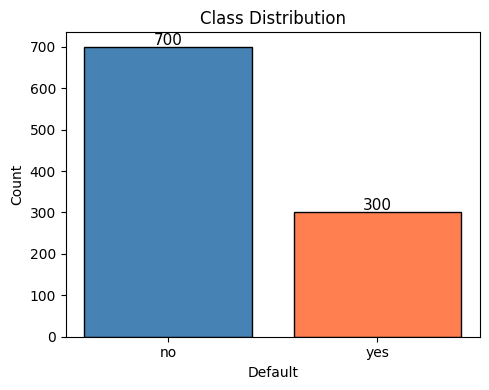

In [62]:
# Check class distribution
print('Class distribution (default):')
print(df['default'].value_counts())
print(f'\nDefault rate: {(df["default"]=="yes").mean():.3f}')

# Plot class distribution
plt.figure(figsize=(5, 4))
counts = df['default'].value_counts()
plt.bar(counts.index, counts.values, color=['steelblue', 'coral'], edgecolor='black')
plt.title('Class Distribution')
plt.xlabel('Default')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=100)
plt.show()

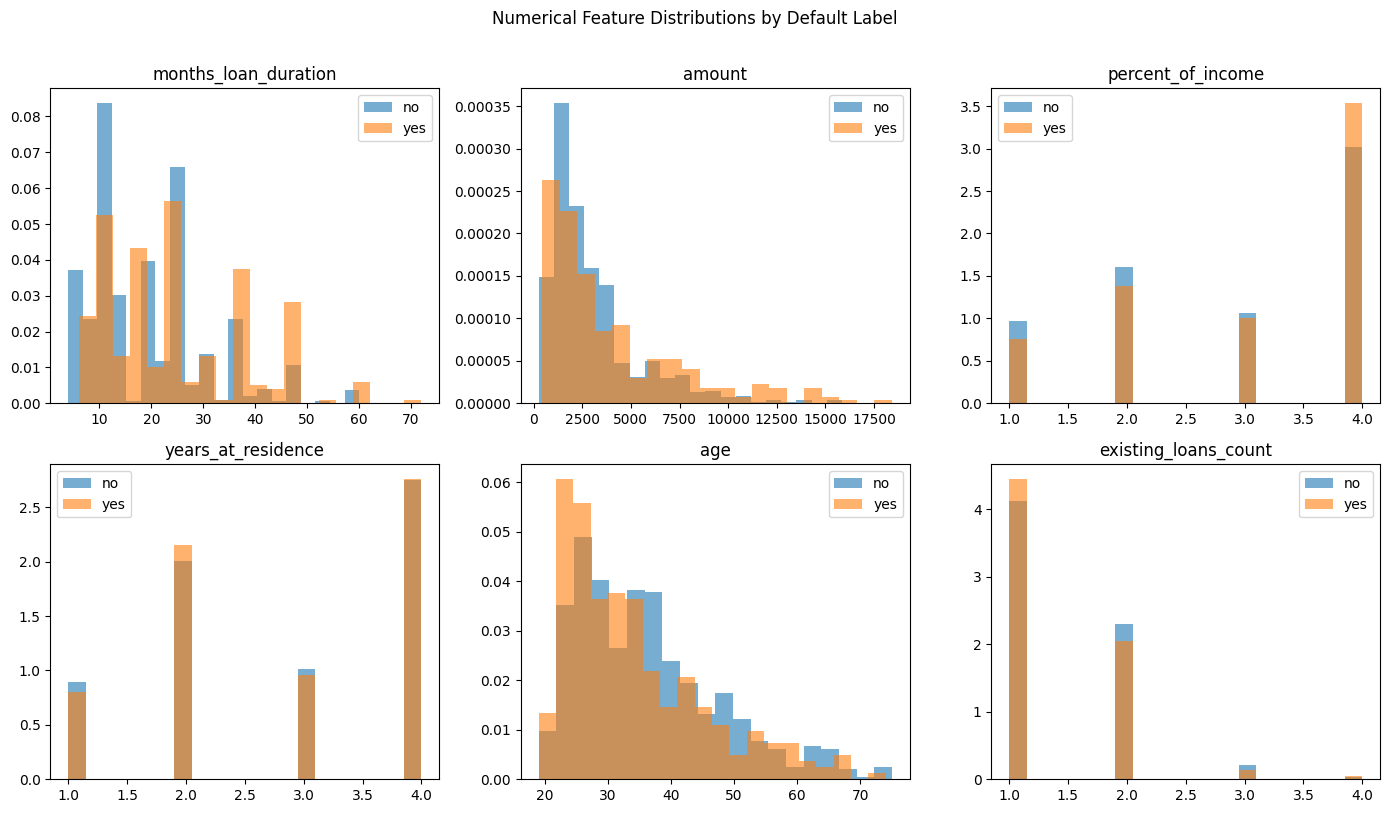

In [63]:
# Distributions of numerical features by default label
numerical_cols = ['months_loan_duration', 'amount', 'percent_of_income',
                   'years_at_residence', 'age', 'existing_loans_count']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(numerical_cols):
    ax = axes[i // 3][i % 3]
    for label, grp in df.groupby('default')[col]:
        ax.hist(grp, bins=20, alpha=0.6, label=label, density=True)
    ax.set_title(col)
    ax.legend()
plt.suptitle('Numerical Feature Distributions by Default Label', y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=100)
plt.show()

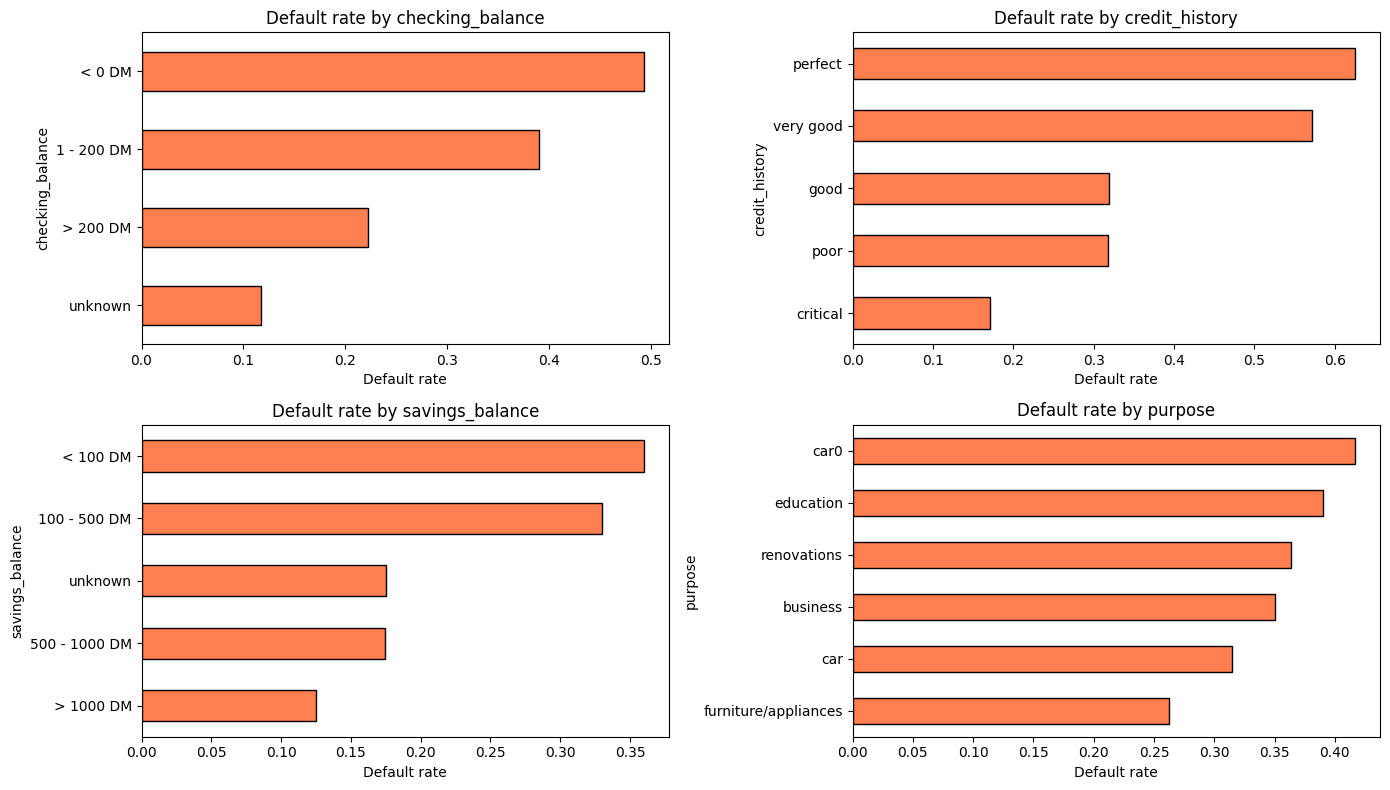

In [64]:
# Show default rate for a few key categorical features
cat_cols = ['checking_balance', 'credit_history', 'savings_balance', 'purpose']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for i, col in enumerate(cat_cols):
    ax = axes[i // 2][i % 2]
    default_rate = df.groupby(col)['default'].apply(lambda x: (x == 'yes').mean())
    default_rate.sort_values().plot(kind='barh', ax=ax, color='coral', edgecolor='black')
    ax.set_title(f'Default rate by {col}')
    ax.set_xlabel('Default rate')
plt.tight_layout()
plt.savefig('categorical_default_rates.png', dpi=100)
plt.show()

## 1.2 Methods

### Preprocessing

The dataset contains a mix of categorical and numerical features. We apply one-hot encoding to categorical columns and standard scaling to numerical ones. The target variable  is encoded as 1 (yes) and 0 (no).

In [65]:
# Encode target
df['default'] = (df['default'] == 'yes').astype(int)

# Separate features and target
categorical_cols = ['checking_balance', 'credit_history', 'purpose', 'savings_balance',
                    'employment_duration', 'other_credit', 'housing', 'job', 'phone']

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df.drop('default', axis=1), columns=categorical_cols, drop_first=False)

X = df_encoded.values.astype(float)
y = df['default'].values

print(f'Number of features after encoding: {X.shape[1]}')

# Stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features - fit on train only, apply to both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')
print(f'Default rate in train: {y_train.mean():.3f}')
print(f'Default rate in test:  {y_test.mean():.3f}')

Number of features after encoding: 44

Train size: 800, Test size: 200
Default rate in train: 0.300
Default rate in test:  0.300


### Non-DL Method: Random Forest

In [66]:
# Train Random Forest with 100 trees
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]  # probability of default

print('=== Random Forest ===')
print(f'Accuracy:       {accuracy_score(y_test, rf_pred):.4f}')
print(f'F1 (macro):     {f1_score(y_test, rf_pred, average="macro"):.4f}')
print(f'Precision (macro): {precision_score(y_test, rf_pred, average="macro"):.4f}')
print(f'Recall (macro):    {recall_score(y_test, rf_pred, average="macro"):.4f}')
print(f'ROC-AUC:        {roc_auc_score(y_test, rf_prob):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=['No Default', 'Default']))

=== Random Forest ===
Accuracy:       0.7650
F1 (macro):     0.6802
Precision (macro): 0.7305
Recall (macro):    0.6655
ROC-AUC:        0.7862

Classification Report:
              precision    recall  f1-score   support

  No Default       0.79      0.91      0.84       140
     Default       0.68      0.42      0.52        60

    accuracy                           0.77       200
   macro avg       0.73      0.67      0.68       200
weighted avg       0.75      0.77      0.75       200



### DL Method: Multi-Layer Perceptron

In [67]:
# Train MLP with two hidden layers (64 and 32 units)
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp.fit(X_train, y_train)

mlp_pred = mlp.predict(X_test)
mlp_prob = mlp.predict_proba(X_test)[:, 1]

print('=== MLP Neural Network ===')
print(f'Accuracy:       {accuracy_score(y_test, mlp_pred):.4f}')
print(f'F1 (macro):     {f1_score(y_test, mlp_pred, average="macro"):.4f}')
print(f'Precision (macro): {precision_score(y_test, mlp_pred, average="macro"):.4f}')
print(f'Recall (macro):    {recall_score(y_test, mlp_pred, average="macro"):.4f}')
print(f'ROC-AUC:        {roc_auc_score(y_test, mlp_prob):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, mlp_pred, target_names=['No Default', 'Default']))

=== MLP Neural Network ===
Accuracy:       0.7100
F1 (macro):     0.6184
Precision (macro): 0.6417
Recall (macro):    0.6119
ROC-AUC:        0.7325

Classification Report:
              precision    recall  f1-score   support

  No Default       0.76      0.86      0.81       140
     Default       0.52      0.37      0.43        60

    accuracy                           0.71       200
   macro avg       0.64      0.61      0.62       200
weighted avg       0.69      0.71      0.69       200



## 1.3 Performance Comparison and Analysis

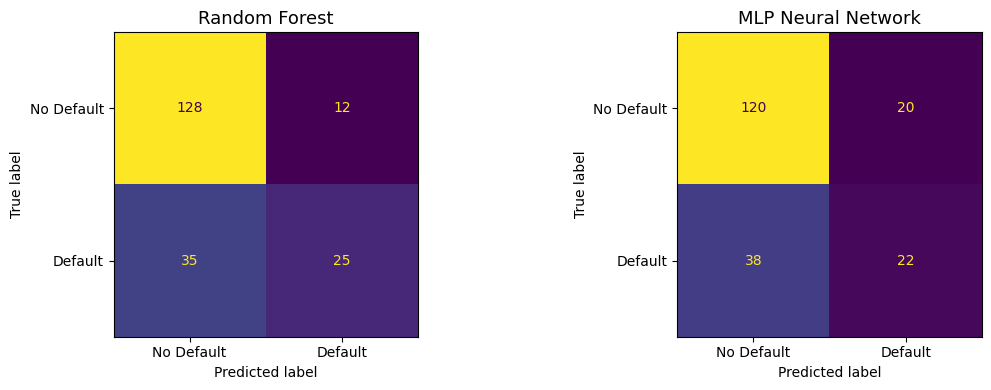

In [11]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm_rf = confusion_matrix(y_test, rf_pred)
cm_mlp = confusion_matrix(y_test, mlp_pred)

ConfusionMatrixDisplay(cm_rf, display_labels=['No Default', 'Default']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Random Forest', fontsize=13)

ConfusionMatrixDisplay(cm_mlp, display_labels=['No Default', 'Default']).plot(ax=axes[1], colorbar=False)
axes[1].set_title('MLP Neural Network', fontsize=13)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100)
plt.show()

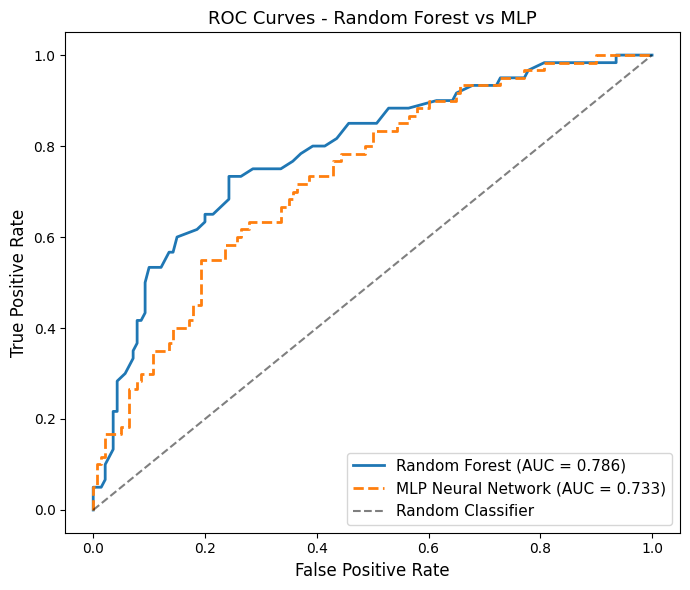

In [12]:
# ROC curves
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_prob)

auc_rf = roc_auc_score(y_test, rf_prob)
auc_mlp = roc_auc_score(y_test, mlp_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', linewidth=2)
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP Neural Network (AUC = {auc_mlp:.3f})', linewidth=2, linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Random Forest vs MLP', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=100)
plt.show()

In [13]:
# comparison table
results = pd.DataFrame({
    'Model': ['Random Forest', 'MLP Neural Network'],
    'Accuracy': [
        round(accuracy_score(y_test, rf_pred), 4),
        round(accuracy_score(y_test, mlp_pred), 4)
    ],
    'F1 (macro)': [
        round(f1_score(y_test, rf_pred, average='macro'), 4),
        round(f1_score(y_test, mlp_pred, average='macro'), 4)
    ],
    'Precision (macro)': [
        round(precision_score(y_test, rf_pred, average='macro'), 4),
        round(precision_score(y_test, mlp_pred, average='macro'), 4)
    ],
    'Recall (macro)': [
        round(recall_score(y_test, rf_pred, average='macro'), 4),
        round(recall_score(y_test, mlp_pred, average='macro'), 4)
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, rf_prob), 4),
        round(roc_auc_score(y_test, mlp_prob), 4)
    ]
})

print('Performance Comparison:')
print(results.to_string(index=False))

Performance Comparison:
             Model  Accuracy  F1 (macro)  Precision (macro)  Recall (macro)  ROC-AUC
     Random Forest     0.765      0.6802             0.7305          0.6655   0.7862
MLP Neural Network     0.710      0.6184             0.6417          0.6119   0.7325


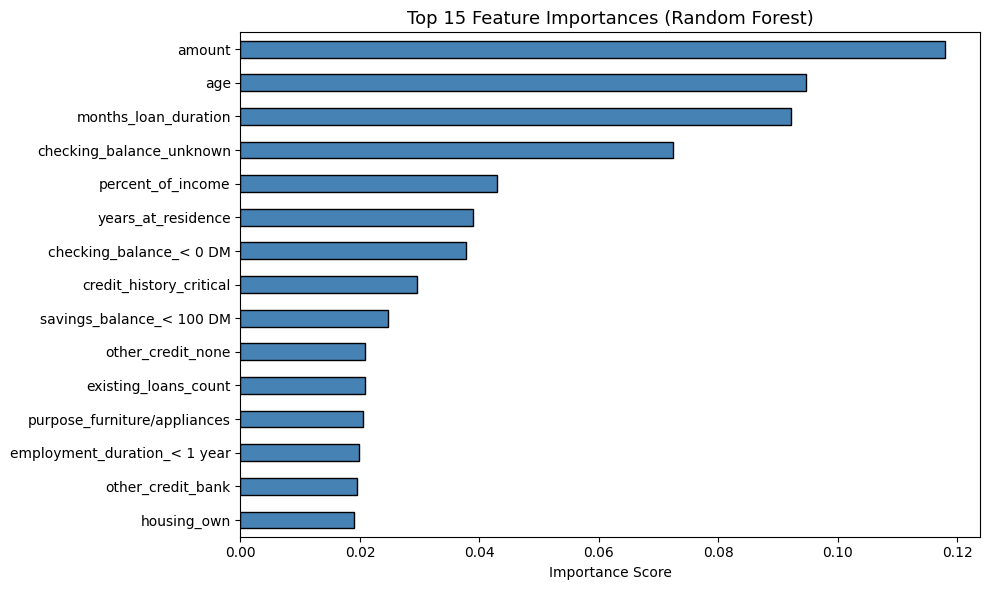

Top 10 most important features:
amount                      0.117906
age                         0.094600
months_loan_duration        0.092102
checking_balance_unknown    0.072374
percent_of_income           0.043001
years_at_residence          0.038983
checking_balance_< 0 DM     0.037674
credit_history_critical     0.029507
savings_balance_< 100 DM    0.024703
other_credit_none           0.020871
dtype: float64


In [14]:
# Feature importances from Random Forest
feature_names = list(df_encoded.columns)
importances = pd.Series(rf.feature_importances_, index=feature_names)
top_features = importances.nlargest(15)

plt.figure(figsize=(10, 6))
top_features.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances (Random Forest)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()

print('Top 10 most important features:')
print(top_features.head(10))

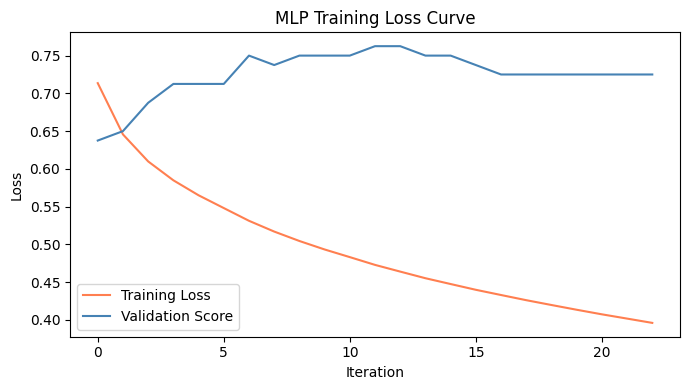

Training stopped after 23 iterations


In [15]:
# Plot MLP training loss curve to check convergence
plt.figure(figsize=(7, 4))
plt.plot(mlp.loss_curve_, label='Training Loss', color='coral')
if hasattr(mlp, 'validation_scores_') and mlp.validation_scores_ is not None:
    plt.plot(mlp.validation_scores_, label='Validation Score', color='steelblue')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Training Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig('mlp_loss_curve.png', dpi=100)
plt.show()

print(f'Training stopped after {mlp.n_iter_} iterations')